# Leviathan – Phase 2  
## Tail Risk Validation under Structural Regime Conditioning

---

## Research Objective

Evaluate whether `supply_high` gating improves left-tail risk characteristics conditional on structural regime states.

Phase 2 is not designed to increase mean return.  
It tests whether a structural exposure gate reduces downside vulnerability.

We report both (i) full-series performance where OFF periods are set to 0 return (capital deployment view) and (ii) invested-only performance conditional on invested_p2==1 (conditional distribution view). Tail conclusions are drawn primarily from the invested-only distribution, while drawdown results are presented on the full-series equity curve.

---

## Structural Hypothesis

- Elevated housing supply signals inventory stress.
- In fragile affordability regimes, excess supply may amplify downside risk.
- Reducing exposure when `supply_high = 1` should compress the left tail of forward returns.

Phase 2 implements a regime-aware exposure gate prior to 1-quarter forward return realization.

---

## Methodological Framework

- Quarterly frequency
- 1-quarter forward return target
- Regime labels fixed ex-ante
- No look-ahead bias
- Gating rule pre-specified

Metrics evaluated:

- Mean
- Volatility
- Sharpe
- p05 (5th percentile)
- Minimum return

Tail metrics are emphasized as Phase 2 is a downside-control module.


In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def find_repo_root(start="."):
    p = Path(start).resolve()
    for _ in range(10):
        if (p / "outputs").exists():
            return p
        p = p.parent
    raise FileNotFoundError("Cannot find repo root containing /outputs")

ROOT = find_repo_root()
print("ROOT =", ROOT)

df = pd.read_csv(
    ROOT / "outputs" / "phase2" / "phase2_strategy_series.csv",
    parse_dates=["date"],
).sort_values("date").reset_index(drop=True)

df.columns = df.columns.str.strip()

df = df[df["ret_1q_fwd"].notna()].reset_index(drop=True)

df.head()


ROOT = /Users/axl/Mispricing Model_Leviathan/leviathan-model


,date,ret_1q_fwd,strat_p1,strat_p2,invested_p2,dti,regime,supply_high
0,1999-03-31,0.008659,0.008659,0.008659,1,83.132765,0,0
1,1999-06-30,0.017159,0.017159,0.017159,1,91.074562,1,0
2,1999-09-30,-0.005264,-0.005264,-0.005264,1,84.070830,0,0
3,1999-12-31,0.008306,0.008306,0.008306,1,85.778245,0,0
4,2000-03-31,0.003158,0.003158,0.003158,1,88.622364,0,0


In [83]:
def sharpe(x: pd.Series) -> float:
    x = x.dropna()
    return float(x.mean() / x.std(ddof=1))

def summarize(x: pd.Series) -> dict:
    x = x.dropna()
    m = x.mean()
    v = x.std(ddof=1)
    return {
        "n": int(len(x)),
        "mean": float(m),
        "vol": float(v),
        "sharpe": float(m / v) if v > 0 else np.nan,
        "p05": float(x.quantile(0.05)),
        "min": float(x.min()),
        "max": float(x.max()),
    }

def equity_from_logret(x: pd.Series) -> pd.Series:
    return np.exp(pd.Series(x).fillna(0).cumsum())

def drawdown(eq: pd.Series) -> pd.Series:
    eq = pd.Series(eq)
    peak = eq.cummax()
    return eq / peak - 1.0


In [84]:
inv = df["invested_p2"].eq(1)

print("Exposure (mean invested_p2):", float(df["invested_p2"].mean()))

print("\n=== FULL SERIES (off=0) ===")
print("Baseline:", summarize(df["ret_1q_fwd"]))
print("Phase1  :", summarize(df["strat_p1"]))
print("Phase2  :", summarize(df["strat_p2"]))

print("\n=== INVESTED-ONLY (conditional on invested_p2==1) ===")
print("Ret when invested:", summarize(df.loc[inv, "ret_1q_fwd"]))
print("Ret when OFF      :", summarize(df.loc[~inv, "ret_1q_fwd"]))


Exposure (mean invested_p2): 0.8349514563106796

=== FULL SERIES (off=0) ===
Baseline: {'n': 103, 'mean': 0.006838602174878389, 'vol': 0.016710483877571965, 'sharpe': 0.4092402245788252, 'p05': -0.03685921740054664, 'min': -0.0495772839135657, 'max': 0.0410506716924041}
Phase1  : {'n': 103, 'mean': 0.005839970760132161, 'vol': 0.01641812161227927, 'sharpe': 0.3557027349440749, 'p05': -0.03685921740054664, 'min': -0.0495772839135657, 'max': 0.0410506716924041}
Phase2  : {'n': 103, 'mean': 0.009232673995957518, 'vol': 0.009429962760336844, 'sharpe': 0.9790785213692319, 'p05': -0.0023709780165336288, 'min': -0.0095672178247863, 'max': 0.037174740375339}

=== INVESTED-ONLY (conditional on invested_p2==1) ===
Ret when invested: {'n': 86, 'mean': 0.011057737460274702, 'vol': 0.009289270163628943, 'sharpe': 1.1903774209915852, 'p05': -0.0031625655414635, 'min': -0.0095672178247863, 'max': 0.037174740375339}
Ret when OFF      : {'n': 17, 'mean': -0.0145052586806559, 'vol': 0.027240124603704043

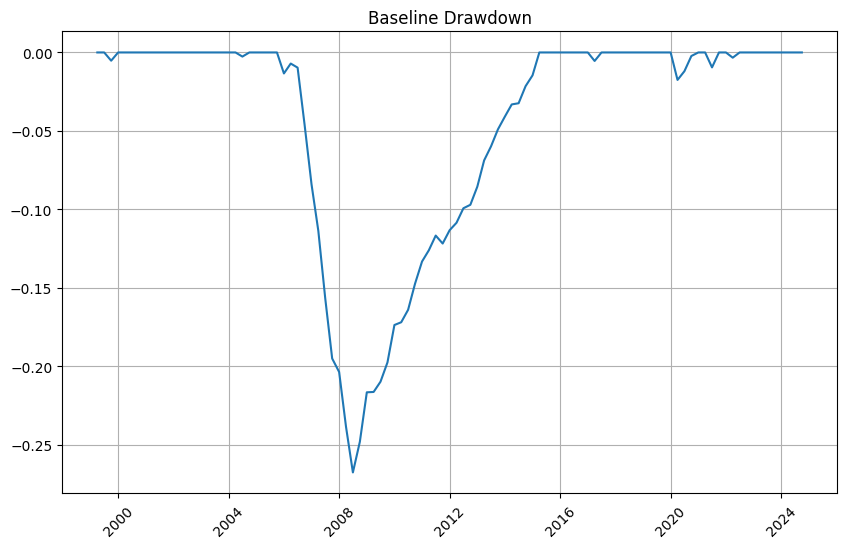

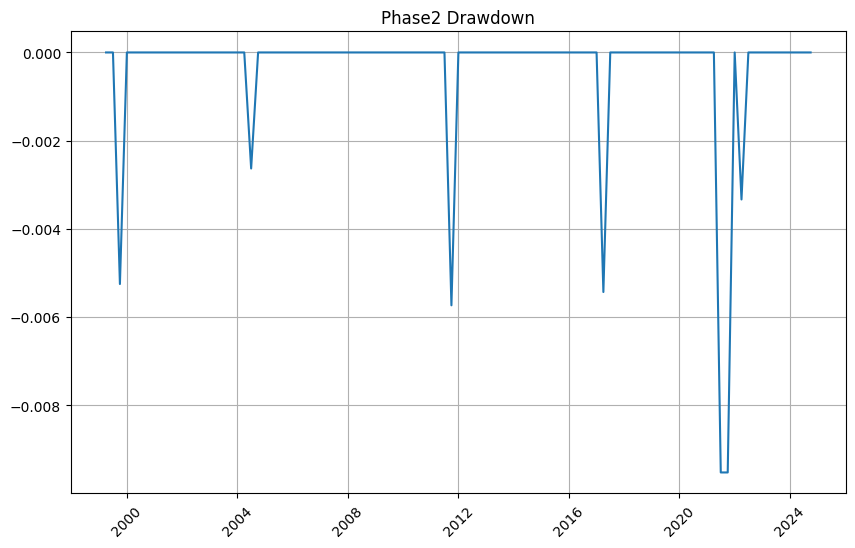

MaxDD baseline: -0.26767191952699665
MaxDD phase2  : -0.009521597598464604


In [85]:
eq_base = equity_from_logret(df["ret_1q_fwd"])
eq_p2   = equity_from_logret(df["strat_p2"])

dd_base = drawdown(eq_base)
dd_p2   = drawdown(eq_p2)

plt.figure()
plt.plot(df["date"], dd_base)
plt.title("Baseline Drawdown")
plt.xticks(rotation=45)
plt.show()

plt.figure()
plt.plot(df["date"], dd_p2)
plt.title("Phase2 Drawdown")
plt.xticks(rotation=45)
plt.show()

print("MaxDD baseline:", float(dd_base.min()))
print("MaxDD phase2  :", float(dd_p2.min()))


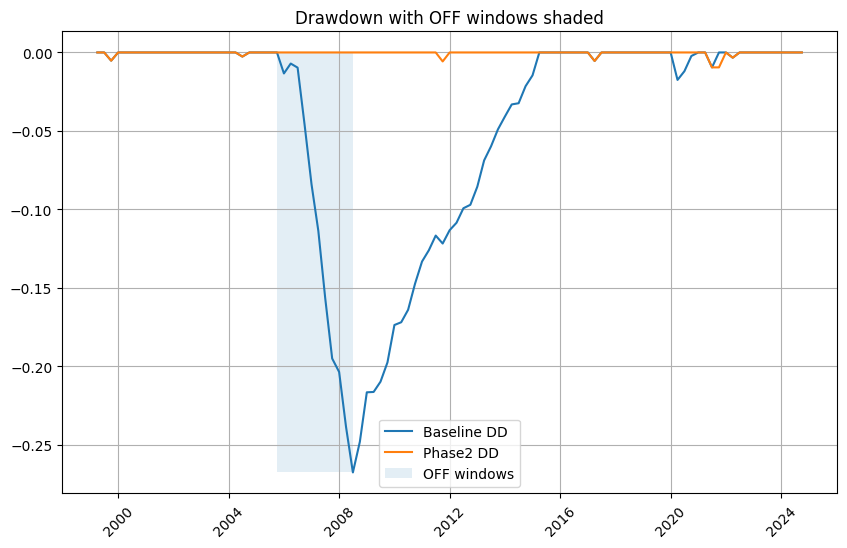

In [86]:
off = df["invested_p2"].eq(0)
low = min(dd_base.min(), dd_p2.min())

plt.figure()
plt.plot(df["date"], dd_base, label="Baseline DD")
plt.plot(df["date"], dd_p2, label="Phase2 DD")
plt.fill_between(df["date"], low, 0, where=off, alpha=0.12, label="OFF windows")
plt.legend()
plt.title("Drawdown with OFF windows shaded")
plt.xticks(rotation=45)
plt.show()


In [98]:
crisis = df["date"].between("2005-01-01", "2009-12-31")
noncr  = ~crisis

inv = df["invested_p2"].eq(1)

def summarize_masked(x, mask):
    return summarize(pd.Series(x).where(mask).dropna())

print("=== CRISIS 2005-2009 (FULL SERIES, off=0) ===")
print("Baseline:", summarize(df.loc[crisis, "ret_1q_fwd"]))
print("Phase2  :", summarize(df.loc[crisis, "strat_p2"]))

print("\n=== CRISIS 2005-2009 (INVESTED-ONLY) ===")
print("Baseline (invested==1):", summarize_masked(df.loc[crisis, "ret_1q_fwd"], inv.loc[crisis]))
print("Phase2   (invested==1):", summarize_masked(df.loc[crisis, "ret_1q_fwd"], inv.loc[crisis]))

print("\n=== NON-CRISIS (FULL SERIES, off=0) ===")
print("Baseline:", summarize(df.loc[noncr, "ret_1q_fwd"]))
print("Phase2  :", summarize(df.loc[noncr, "strat_p2"]))

print("\n=== NON-CRISIS (INVESTED-ONLY) ===")
print("Baseline (invested==1):", summarize_masked(df.loc[noncr, "ret_1q_fwd"], inv.loc[noncr]))
print("Phase2   (invested==1):", summarize_masked(df.loc[noncr, "ret_1q_fwd"], inv.loc[noncr]))



=== CRISIS 2005-2009 (FULL SERIES, off=0) ===
Baseline: {'n': 20, 'mean': -0.00822881257800301, 'vol': 0.028490409166250726, 'sharpe': -0.28882746225177863, 'p05': -0.04681579402689326, 'min': -0.0495772839135657, 'max': 0.0410506716924041}
Phase2  : {'n': 20, 'mean': 0.00522206046059937, 'vol': 0.00998387443928479, 'sharpe': 0.5230494926950885, 'p05': 0.0, 'min': 0.0, 'max': 0.0292869764440562}

=== CRISIS 2005-2009 (INVESTED-ONLY) ===
Baseline (invested==1): {'n': 7, 'mean': 0.014920172744569629, 'vol': 0.012117443718026205, 'sharpe': 1.2312970533854444, 'p05': 0.00041178208499127007, 'min': 0.0002843337117459, 'max': 0.0292869764440562}
Phase2   (invested==1): {'n': 7, 'mean': 0.014920172744569629, 'vol': 0.012117443718026205, 'sharpe': 1.2312970533854444, 'p05': 0.00041178208499127007, 'min': 0.0002843337117459, 'max': 0.0292869764440562}

=== NON-CRISIS (FULL SERIES, off=0) ===
Baseline: {'n': 83, 'mean': 0.010469304524970293, 'vol': 0.009516030826458112, 'sharpe': 1.1001755580553

In [88]:
rows = []
for r in sorted(df["regime"].dropna().unique()):
    sub = df[df["regime"].eq(r)]
    rows.append({"regime": int(r), "baseline": summarize(sub["ret_1q_fwd"]), "phase2": summarize(sub["strat_p2"])})

reg_tbl = pd.DataFrame({
    "regime": [x["regime"] for x in rows],
    "baseline_mean": [x["baseline"]["mean"] for x in rows],
    "baseline_p05":  [x["baseline"]["p05"] for x in rows],
    "baseline_min":  [x["baseline"]["min"] for x in rows],
    "baseline_sh":   [x["baseline"]["sharpe"] for x in rows],
    "phase2_mean":   [x["phase2"]["mean"] for x in rows],
    "phase2_p05":    [x["phase2"]["p05"] for x in rows],
    "phase2_min":    [x["phase2"]["min"] for x in rows],
    "phase2_sh":     [x["phase2"]["sharpe"] for x in rows],
}).sort_values("regime")

reg_tbl


,regime,baseline_mean,baseline_p05,baseline_min,baseline_sh,phase2_mean,phase2_p05,phase2_min,phase2_sh
0,0,0.002157,-0.042000,-0.049577,0.109865,0.006641,0.000000,-0.009567,0.862236
1,1,0.012203,-0.003092,-0.005749,1.174393,0.012203,-0.003092,-0.005749,1.174393


In [89]:
sub = df[df["regime"].eq(0)].copy()

tail_tbl = (
    sub.groupby("supply_high")["ret_1q_fwd"]
    .apply(lambda x: pd.Series({
        "n": len(x),
        "mean": x.mean(),
        "p05": x.quantile(0.05),
        "p10": x.quantile(0.10),
        "min": x.min(),
    }))
    .reset_index()
)

tail_tbl


,supply_high,level_1,ret_1q_fwd
0,0,n,38.000000
1,0,mean,0.009612
2,0,p05,-0.000123
3,0,p10,0.002945
4,0,min,-0.009567
5,1,n,17.000000
6,1,mean,-0.014505
7,1,p05,-0.047252
8,1,p10,-0.045593
9,1,min,-0.049577


In [100]:
from scipy.stats import fisher_exact

sub = df[df["regime"].eq(0)].copy()

thr = sub["ret_1q_fwd"].quantile(0.10)   
sub["crash"] = (sub["ret_1q_fwd"] < thr).astype(int)

tab = pd.crosstab(sub["supply_high"], sub["crash"])
print(tab)

oddsratio, p = fisher_exact(tab.values)
print("Fisher exact p-value:", p)
print("Odds ratio:", oddsratio)


crash         0  1
supply_high       
0            38  0
1            11  6
Fisher exact p-value: 0.00042691061558986084
Odds ratio: inf


In [91]:
san = pd.read_csv(ROOT / "outputs" / "phase2" / "phase2_sanity.csv", parse_dates=["date"]).sort_values("date")
san.columns = san.columns.str.strip()

tmp = df.merge(san[["date", "supply_value"]], on="date", how="left")

qs = np.arange(0.60, 0.96, 0.05)
rows = []

for q in qs:
    thr = tmp["supply_value"].quantile(q)
    supply_hi = (tmp["supply_value"] >= thr).astype(int)

    invested = ~((tmp["regime"].eq(0)) & (supply_hi.eq(1)))
    strat = tmp["ret_1q_fwd"].where(invested, 0.0)

    rows.append({
        "q": float(q),
        "exposure": float(invested.mean()),
        "sharpe_full_series": float(sharpe(strat)),
        "p05_full_series": float(pd.Series(strat).dropna().quantile(0.05)),
    })

sens = pd.DataFrame(rows)
sens


,q,exposure,sharpe_full_series,p05_full_series
0,0.60,0.825243,0.907648,-0.003268
1,0.65,0.854369,0.880218,-0.005071
2,0.70,0.893204,0.913882,-0.005071
3,0.75,0.922330,0.704298,-0.005719
4,0.80,0.932039,0.642222,-0.009185
5,0.85,0.941748,0.550991,-0.013082
6,0.90,0.951456,0.564861,-0.013082
7,0.95,0.970874,0.486666,-0.017247


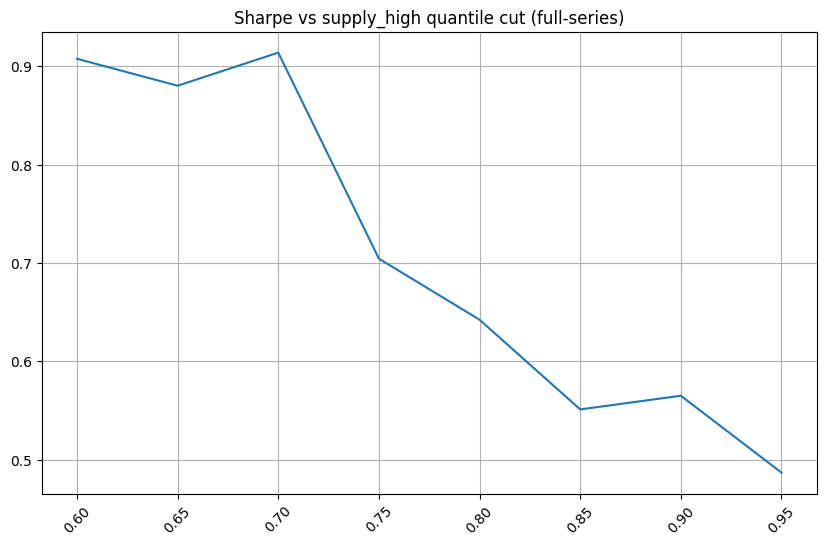

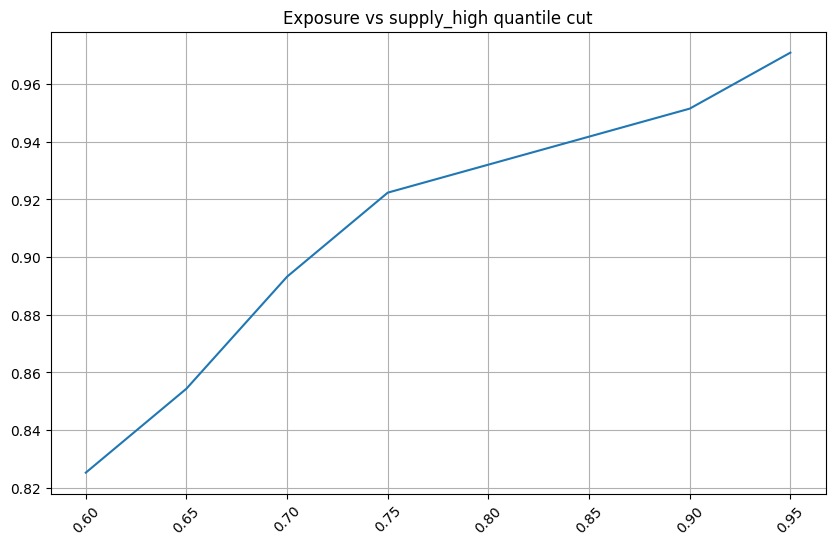

In [92]:
plt.figure()
plt.plot(sens["q"], sens["sharpe_full_series"])
plt.title("Sharpe vs supply_high quantile cut (full-series)")
plt.xticks(rotation=45)
plt.show()

plt.figure()
plt.plot(sens["q"], sens["exposure"])
plt.title("Exposure vs supply_high quantile cut")
plt.xticks(rotation=45)
plt.show()


In [101]:
print("df columns:", list(df.columns))
print("san columns:", list(san.columns))

full = san.merge(df[["date", "ret_1q_fwd"] + [c for c in ["regime","regime_label","regime_state"] if c in df.columns]],
                 on="date", how="inner").sort_values("date")
print("full columns:", list(full.columns))

print("Columns containing 'regime':", [c for c in full.columns if "regime" in c.lower()])
full.head()


df columns: ['date', 'ret_1q_fwd', 'strat_p1', 'strat_p2', 'invested_p2', 'dti', 'regime', 'supply_high']
san columns: ['date', 'dti', 'real_rate', 'regime', 'real_price_index', 'fwd_ret_4q', 'supply_metric_name', 'supply_high', 'supply_q', 'permits', 'supply_value']
full columns: ['date', 'dti', 'real_rate', 'regime_x', 'real_price_index', 'fwd_ret_4q', 'supply_metric_name', 'supply_high', 'supply_q', 'permits', 'supply_value', 'ret_1q_fwd', 'regime_y']
Columns containing 'regime': ['regime_x', 'regime_y']


,date,dti,real_rate,regime_x,real_price_index,fwd_ret_4q,supply_metric_name,supply_high,supply_q,permits,supply_value,ret_1q_fwd,regime_y
0,1999-03-31,83.132765,0.182830,0,100.000000,0.028860,months_supply,0,NaN,1705.666667,4.000000,0.008659,0
1,1999-06-30,91.074562,-0.261601,1,100.869636,0.023360,months_supply,0,NaN,1647.333333,3.933333,0.017159,1
2,1999-09-30,84.070830,1.153580,0,102.615396,0.010924,months_supply,0,NaN,1634.666667,4.166667,-0.005264,0
3,1999-12-31,85.778245,1.566901,0,102.076655,0.034215,months_supply,0,NaN,1668.000000,4.266667,0.008306,0
4,2000-03-31,88.622364,0.071797,0,102.928067,0.039290,months_supply,0,NaN,1690.000000,4.300000,0.003158,0


In [102]:
split = pd.Timestamp("2004-12-31")

san2 = san.copy()
if "Regime" in san2.columns and "regime" not in san2.columns:
    san2 = san2.rename(columns={"Regime": "regime"})

full = san2.merge(
    df[["date", "ret_1q_fwd", "regime"]],
    on="date",
    how="inner",
    suffixes=("_san", "_df"),
).sort_values("date").reset_index(drop=True)

if "regime_df" not in full.columns:
    raise KeyError(f"Expected 'regime_df' not found. Columns: {list(full.columns)}")

full["regime"] = full["regime_df"]

mismatch = (full["regime_san"] != full["regime_df"]).sum() if "regime_san" in full.columns else None
print("Regime mismatch count (san vs df):", mismatch)

train = full[full["date"] <= split].copy()
test  = full[full["date"] >  split].copy()

q = 0.90
thr_supply = train["supply_value"].quantile(q)

test["supply_high_oos"] = (test["supply_value"] >= thr_supply).astype(int)
test["invested_oos"] = ~((test["regime"].eq(0)) & (test["supply_high_oos"].eq(1)))
test["strat_oos"] = test["ret_1q_fwd"].where(test["invested_oos"], 0.0)

print("OOS exposure:", float(test["invested_oos"].mean()))
print("OOS baseline:", summarize(test["ret_1q_fwd"]))
print("OOS strat   :", summarize(test["strat_oos"]))


Regime mismatch count (san vs df): 0
OOS exposure: 0.5063291139240507
OOS baseline: {'n': 79, 'mean': 0.005695052490724946, 'vol': 0.018199110405323887, 'sharpe': 0.3129302676826962, 'p05': -0.03914793098425967, 'min': -0.0495772839135657, 'max': 0.0410506716924041}
OOS strat   : {'n': 79, 'mean': 0.006074935573102745, 'vol': 0.00911893468175227, 'sharpe': 0.6661891750644059, 'p05': 0.0, 'min': -0.0057489580836991, 'max': 0.0292869764440562}


In [94]:
out_dir = ROOT / "outputs" / "phase2" / "tail_validation_exports"
out_dir.mkdir(parents=True, exist_ok=True)

reg_tbl.to_csv(out_dir / "regime_summary.csv", index=False)
tail_tbl.to_csv(out_dir / "regime0_supply_tail.csv", index=False)
sens.to_csv(out_dir / "supply_cut_sensitivity.csv", index=False)

print("Saved to:", out_dir)


Saved to: /Users/axl/Mispricing Model_Leviathan/leviathan-model/outputs/phase2/tail_validation_exports
